In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [35]:
df = sns.load_dataset('titanic')

print("Titanic dataset loaded successfully!")
print(df.head())

Titanic dataset loaded successfully!
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [36]:
print("First 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nDataset information:")
print(df.info())

print("\nStatistical description:")
print(df.describe())

First 5 rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset shape:
(891, 15)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ----

In [37]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


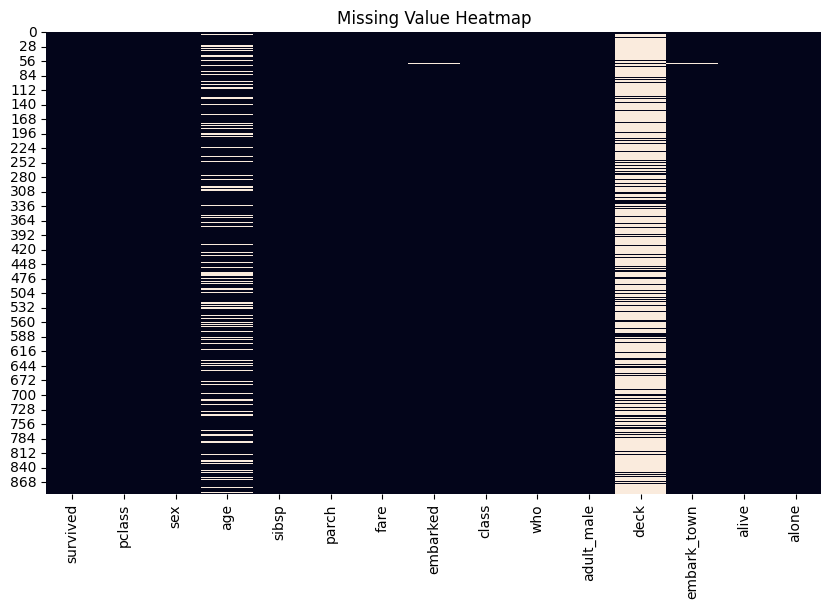

In [38]:
plt.figure(figsize=(10, 6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Value Heatmap")
plt.show()

In [39]:
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      0
alive            0
alone            0
dtype: int64


Survival by Sex:
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64


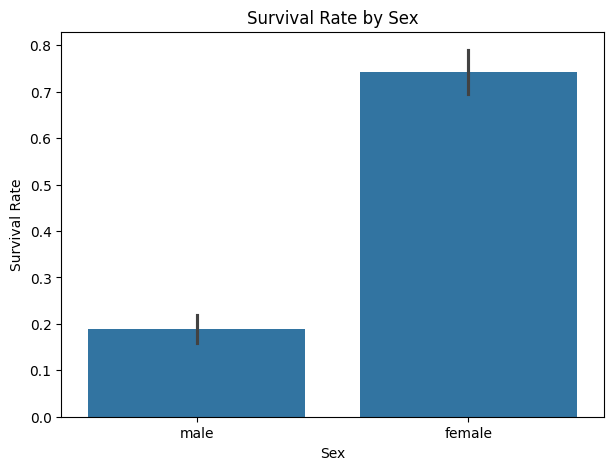

In [40]:
print("Survival by Sex:")
print(df.groupby('sex')['survived'].mean())

plt.figure(figsize=(7, 5))

sns.barplot(data=df, x='sex', y='survived')

plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.xlabel("Sex")
plt.show()

Survival by Class:
class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64


/tmp/ipykernel_660/588552863.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('class')['survived'].mean())


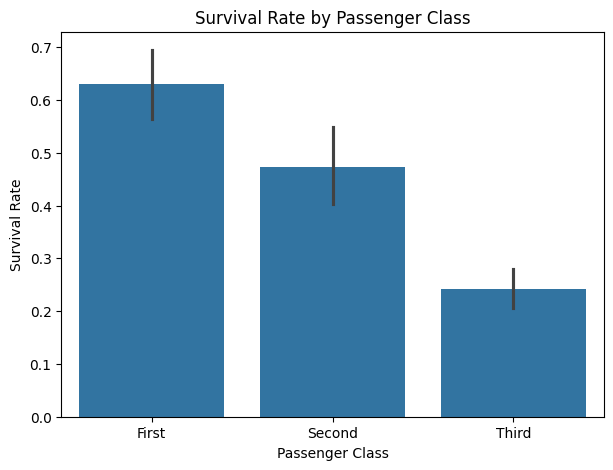

In [41]:
print("Survival by Class:")
print(df.groupby('class')['survived'].mean())

plt.figure(figsize=(7, 5))

sns.barplot(data=df, x='class', y='survived')

plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")
plt.show()

In [42]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior']
)

print(df.groupby('age_group', observed=False)['survived'].mean())

age_group
Child          0.579710
Teenager       0.428571
Young Adult    0.353271
Adult          0.400000
Senior         0.227273
Name: survived, dtype: float64


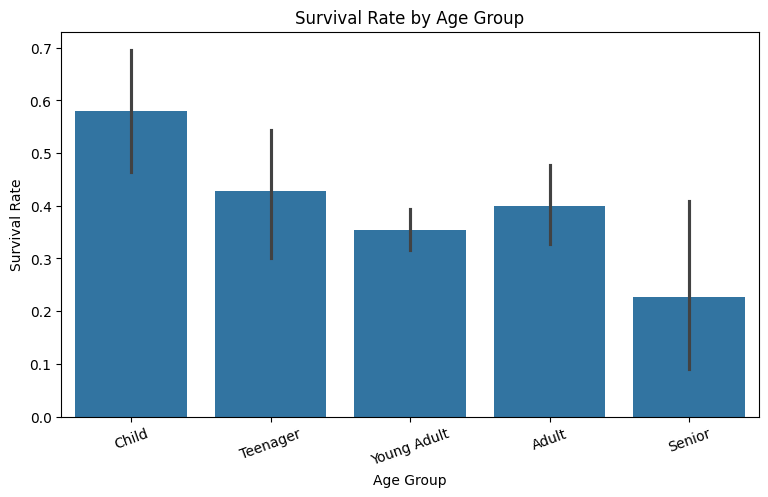

In [43]:
plt.figure(figsize=(9, 5))

sns.barplot(data=df, x='age_group', y='survived')

plt.title("Survival Rate by Age Group")
plt.ylabel("Survival Rate")
plt.xlabel("Age Group")
plt.xticks(rotation=20)
plt.show()

In [44]:
lifecycle_mapping = {
    'Child': 'Childhood',
    'Teenager': 'Adolescence',
    'Young Adult': 'Young Adulthood',
    'Adult': 'Adulthood',
    'Senior': 'Old Age'
}

df['lifecycle_stage'] = df['age_group'].map(lifecycle_mapping)

print(df[['age', 'age_group', 'lifecycle_stage']].head(10))

    age    age_group  lifecycle_stage
0  22.0  Young Adult  Young Adulthood
1  38.0        Adult        Adulthood
2  26.0  Young Adult  Young Adulthood
3  35.0  Young Adult  Young Adulthood
4  35.0  Young Adult  Young Adulthood
5  28.0  Young Adult  Young Adulthood
6  54.0        Adult        Adulthood
7   2.0        Child        Childhood
8  27.0  Young Adult  Young Adulthood
9  14.0     Teenager      Adolescence


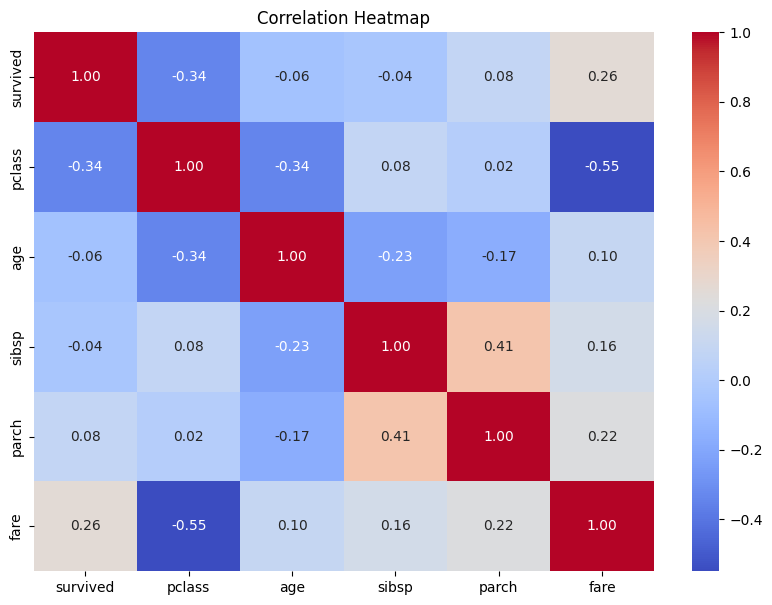

In [45]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()


Overall Survival Rate:
0.3838383838383838


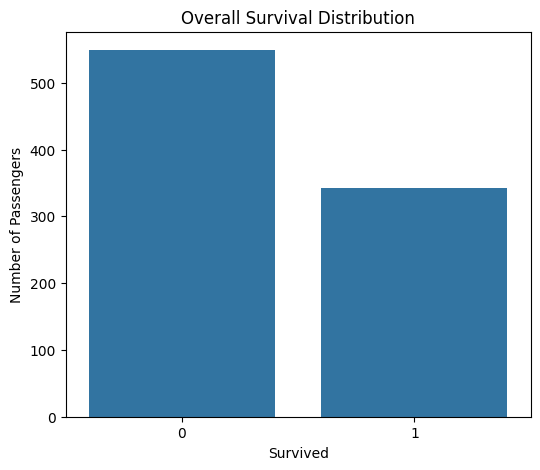

In [46]:
print("Overall Survival Rate:")
print(df['survived'].mean())

plt.figure(figsize=(6, 5))

sns.countplot(data=df, x='survived')

plt.title("Overall Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.show()

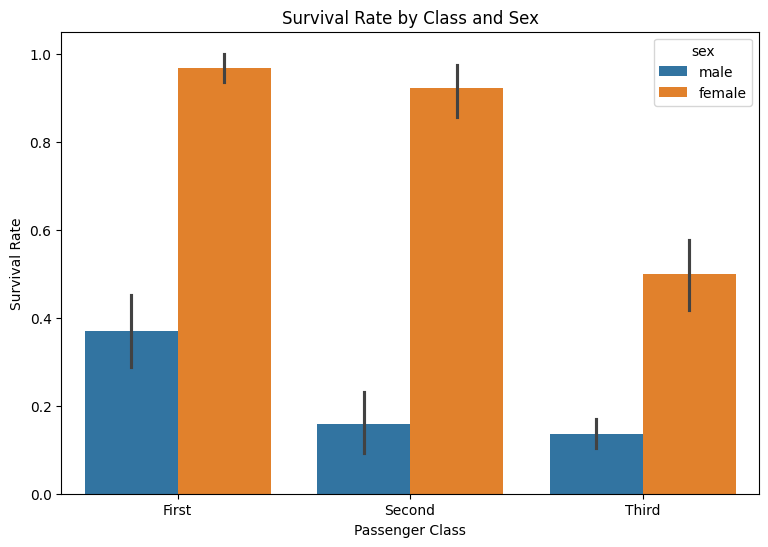

In [47]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=df,
    x='class',
    y='survived',
    hue='sex'
)

plt.title("Survival Rate by Class and Sex")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")
plt.show()

In [48]:
print("Final dataset:")
print(df.head())

print("\nFinal shape:")
print(df.shape)

print("\nFinal columns:")
print(df.columns.tolist())

Final dataset:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone    age_group  \
0    man        True  NaN  Southampton    no  False  Young Adult   
1  woman       False    C    Cherbourg   yes  False        Adult   
2  woman       False  NaN  Southampton   yes   True  Young Adult   
3  woman       False    C  Southampton   yes  False  Young Adult   
4    man        True  NaN  Southampton    no   True  Young Adult   

   lifecycle_stage  
0  Young Adulthood  
1        Adulthood  
2  Young Adulthood  
3  Young Adulthood  
4  Young Adult

In [49]:
from matplotlib.backends.backend_pdf import PdfPages

In [50]:
from matplotlib.backends.backend_pdf import PdfPages

pdf = PdfPages('EDA_Report.pdf')

plt.figure(); sns.heatmap(df.isnull(), cbar=False); plt.title('Missing Value Heatmap'); pdf.savefig(); plt.close()

plt.figure(); sns.barplot(data=df, x='sex', y='survived'); plt.title('Survival Rate by Sex'); pdf.savefig(); plt.close()

plt.figure(); sns.barplot(data=df, x='class', y='survived'); plt.title('Survival Rate by Class'); pdf.savefig(); plt.close()

plt.figure(); sns.heatmap(df.select_dtypes('number').corr(), annot=True); plt.title('Correlation Heatmap'); pdf.savefig(); plt.close()

pdf.close()
print("EDA_Report.pdf created successfully with 4 pages!")

EDA_Report.pdf created successfully with 4 pages!


In [51]:
from google.colab import files
files.download('EDA_Report.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>